# CLASSIFICATION MODEL USING CNN AND RANDOM FOREST

In [24]:
#Importing the necessary libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import RepeatedKFold
import tensorflow.keras.backend as K
import gc

## Extracting the labels from the train.csv file and assigning it to the respective images in the train data

In [25]:
df=pd.read_csv('train.csv')[['id','binary_pred']]
label_encoder=LabelEncoder()
df['encoded_label']=label_encoder.fit_transform(df['binary_pred'])
df['image_path']=df['id'].astype(str)

In [26]:
df

,id,binary_pred,encoded_label,image_path
0,0.png,1,1,0.png
1,1.png,1,1,1.png
2,2.png,1,1,2.png
3,3.png,1,1,3.png
4,4.png,0,0,4.png
...,...,...,...,...
904,904.png,1,1,904.png
905,905.png,1,1,905.png
906,906.png,1,1,906.png
907,907.png,0,0,907.png


# Segregating the image data into two folders --> 0 for healthy and 1 for unhealthy leaves

In [27]:
import os
import shutil

# Load your CSV
df = pd.read_csv('train.csv')

# Create the new folder structure
os.makedirs('dataset', exist_ok=True)

for _, row in df.iterrows():
    img_id = row['id']
    label = str(row['binary_pred'])

    src_path = os.path.join('Dataset\\train\\images', img_id)

    dst_dir = os.path.join('Separated_class', label)
    dst_path = os.path.join(dst_dir, img_id)


    os.makedirs(dst_dir, exist_ok=True)
    shutil.copy(src_path, dst_path)



## Data Pre-Processing

## Image Preprocessing

In [28]:
training_set=tf.keras.utils.image_dataset_from_directory(   # Using keras to load th training data with image size of 128x128x3
    'Separated_class',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=8,
    image_size=(128,128),
    shuffle=True, #For prediction 6
    seed=42,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
    )

Found 909 files belonging to 2 classes.


In [29]:
training_set  # This is done inorder to check for the shape of the input data and the output labels

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [30]:

#Converting the data and the labels into a numpy array
x_all = []
y_all =[]

for images, labels in training_set:
    x_all.append(images.numpy())
    y_all.append(labels.numpy())

x_all=np.concatenate(x_all)
y_all=np.concatenate(y_all)

x_all.shape

(909, 128, 128, 3)

## Building the Model

In [31]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization #For prediction 6
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint #For prediction 6
from tensorflow.keras.optimizers import Adam #For prediction 6


## Building the CNN model

In [32]:
def cnn_model():
    model= Sequential()


    #Building the convolution Layer
    # Using a filter size of 32 in the begining with relu activation and batch normalization after every layer to make sure that the data remains within the range
    model.add(Conv2D(filters=32,kernel_size=4,padding='same',activation='relu',input_shape=[128,128,3]))
    model.add(BatchNormalization()) 
    model.add(Conv2D(filters=32,kernel_size=4,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=2,strides=2))


    model.add(Conv2D(filters=64,kernel_size=4,padding='same',activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64,kernel_size=4,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=2,strides=2))

    model.add(Conv2D(filters=128,kernel_size=4,padding='same',activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=128,kernel_size=4,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=2,strides=2))


    model.add(Conv2D(filters=256,kernel_size=4,padding='same',activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=256,kernel_size=4,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=2,strides=2))


    model.add(Conv2D(filters=512,kernel_size=4,padding='same',activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=512,kernel_size=4,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=2,strides=2))


    model.add(Dropout(0.25)) #To avoid overfitting we use dropout layer with 25 percent of the nodes being dropped at a given step
    model.add(Flatten())
    model.add(Dense(units=1500,activation='relu'))
    model.add(Dropout(0.4))


    model.add(Dense(units=1,activation='sigmoid')) #Output Layer --- Has only one unit as its a binary classification task

    

    return model

In [46]:
results=[]
k_fold=RepeatedKFold(n_splits=5,n_repeats=3, random_state=42)  #Conducting the Kfold validation as given in the question
accuracy=[]
for train_index,val_index in k_fold.split(x_all):
    X_train,X_val= x_all[train_index],x_all[val_index]
    Y_train,Y_val=y_all[train_index],y_all[val_index]


    model=cnn_model()

    #model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])
    model.compile(optimizer=Adam(learning_rate=3e-4),loss='binary_crossentropy',metrics=['accuracy']) #hyperparameter tuning for better results

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    checkpoint = ModelCheckpoint('best_cnn_model.h5', save_best_only=True)
    history=model.fit(X_train,Y_train,validation_data=(X_val,Y_val),epochs=30,callbacks=[early_stop,checkpoint],verbose=0)
    val_loss,val_acc=model.evaluate(X_val,Y_val,verbose=0)

    train_acc=history.history['accuracy'][-1]
    train_loss=history.history['loss'][-1]

    results.append((train_loss,train_acc,val_loss,val_acc))
    cnn_accuracies = [val_acc for (_, _, _, val_acc) in results]  #collecting the cnn_accuracy values for statistical comparision of models


    print(f"Fold {len(results)} → Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


    K.clear_session()
    gc.collect()
    
    

D:\IISc\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 → Train Acc: 0.9340, Val Acc: 0.7912


Fold 2 → Train Acc: 0.9216, Val Acc: 0.7473


Fold 3 → Train Acc: 0.9243, Val Acc: 0.7912


Fold 4 → Train Acc: 0.9326, Val Acc: 0.7692


...

Fold 11 → Train Acc: 0.9450, Val Acc: 0.7637


Fold 12 → Train Acc: 0.9574, Val Acc: 0.8626


Fold 13 → Train Acc: 0.9354, Val Acc: 0.7033


Fold 14 → Train Acc: 0.8790, Val Acc: 0.8132


Fold 15 → Train Acc: 0.9354, Val Acc: 0.8066


In [47]:
from tensorflow.keras.utils import image_dataset_from_directory

test_dataset = image_dataset_from_directory(
    directory='Dataset\\test',
    labels=None,
    label_mode=None,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False  # After training, loading the test data using Keras
)


Found 390 files.


In [48]:
predictions = model.predict(test_dataset)

binary_preds = (predictions.flatten() > 0.5).astype(int)  #Predicting for test data



13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step


In [49]:
import os

# Getting  the full file paths from the test dataset
file_names = test_dataset.file_paths

# Extracting only  the file names (like '909.png')
file_names = [os.path.basename(path) for path in file_names]


In [50]:
import pandas as pd  #saving the output of the classification in a csv file

class_df = pd.DataFrame({
    'id': file_names,
    'binary_pred': binary_preds
})

class_df.to_csv('classification_output.csv', index=False)


## Machine Learning Classification Model

In [51]:
import os
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [52]:
folder_path = 'Dataset\\train\\images'

image_files = glob.glob(os.path.join(folder_path, '*.png'))

mask = []
for file in image_files:
    # Open the image file
    img = Image.open(file)
    # Convert to numpy array
    img_array = np.array(img)
    mask.append(img_array)
    
print("Loaded", len(mask), "images.")


#Using the PCA code from the question 1 to convert the high dimensional data into low dimensional and then performing the classification

from skimage.transform import resize  #Reducing the image size from 256x256x3 to 32x32x3 using skimage

new_height= 32
new_width =32
resized_images=[]
for i, image in enumerate(mask):
    if image.ndim==3:
        channels=image.shape[2]
        resized_img=resize(image,(new_height,new_width,channels),anti_aliasing=True)
    elif image.ndim==2:
        print(f"image{i} shape:{image.shape}")
        resized_img = resize(image, (new_height, new_width), anti_aliasing=True)
    else:
        print("Unexpected image dimensions")
    resized_images.append(resized_img)

mask=resized_images



#flattening the images to convert it into a vector
flattened_images= [img.flatten() for img in mask]
data=np.array(flattened_images)
print(data.shape) # There should be 908 rows and 32x32x3=3072 columns in this array


#Centering the data before performing PCA
mean=np.mean(data,axis=0)


centered_data= data-mean #centering the data of each column
data_std=np.std(centered_data,axis=0) #calculating the standard deviation of the data
standardized_data= centered_data/data_std # Standardizing the data and ready for PCA


#Create the covariance Matrix
covariance_matrix=np.cov(standardized_data,rowvar=False) #compute the covariance matrix
covariance_matrix.shape

eigen_values,eigen_vectors= np.linalg.eigh(covariance_matrix) #compute the eigen values and eigen vectors of the covariance matrix


ascending_order= np.argsort(eigen_values) #Sorting the eigen value indices in ascending order
sorted_index=ascending_order[::-1]  #Converting it to descending order
sorted_eigen_vectors= eigen_vectors[:,sorted_index] #Sorting the eigen vectors based on the corresponding eige value indices

component=200  #selecting the number of principal components 
top_n_eigen_vectors=sorted_eigen_vectors[:,:component] #selecting the top n eigen vectors

reduced_data= np.dot(standardized_data ,top_n_eigen_vectors) #Multiplying standardized data and the eigen vector matrix to get the reduced data


top_n_eigen_values=eigen_values[sorted_index][:component] #taking the top n eigen values to check the variance


sum_of_top_n_eigen_values=np.sum(top_n_eigen_values) 
total_sum=np.sum(eigen_values)
variance=sum_of_top_n_eigen_values/total_sum  #Calculating the variance after  the PCA
print("The number of principal components are",component)
print("The shape of the new data is ",reduced_data.shape)
print("The variance of the data after PCA is ",variance)


Loaded 909 images.
(909, 3072)
The number of principal components are 200
The shape of the new data is  (909, 200)
The variance of the data after PCA is  0.957525710937533


In [53]:
df=pd.read_csv("train.csv")
y=df['binary_pred'].values
print(reduced_data.shape) #Checking the shape of the reduced data and the labels
print(y.shape)


(909, 200)
(909,)


## Training the Random Forest Classifier

In [55]:
#Training a Random Forest Classifier  Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
results=[]
k_fold=RepeatedKFold(n_splits=5,n_repeats=3, random_state=42)
accuracy=[]
for train_index,val_index in k_fold.split(reduced_data):
    X_train,X_val= reduced_data[train_index],reduced_data[val_index]
    y_train,y_val=y[train_index],y[val_index]

    #classifier=RandomForestClassifier(n_estimators=300,random_state=42) ---for trial 1
    #classifier=RandomForestClassifier(n_estimators=300,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',bootstrap=True,random_state=42)
    classifier=RandomForestClassifier(n_estimators=500,max_depth=30,min_samples_split=2,min_samples_leaf=1,max_features='sqrt',bootstrap=True,random_state=42)
    classifier.fit(X_train,y_train)
    y_pred=classifier.predict(X_val)
    val_acc=accuracy_score(y_val,y_pred)
    train_pred=classifier.predict(X_train)
    train_acc=accuracy_score(y_train,train_pred)

    
 

    
    results.append((train_acc, val_acc))
    ml_accuracies = [val_acc for (_, val_acc) in results]

    print(f"Fold {len(results)} → Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")



    
    


Fold 1 → Train Acc: 1.0000, Val Acc: 0.5934
Fold 2 → Train Acc: 1.0000, Val Acc: 0.6264
Fold 3 → Train Acc: 1.0000, Val Acc: 0.6813
Fold 4 → Train Acc: 1.0000, Val Acc: 0.5769
Fold 5 → Train Acc: 1.0000, Val Acc: 0.6464
Fold 6 → Train Acc: 1.0000, Val Acc: 0.6154
Fold 7 → Train Acc: 1.0000, Val Acc: 0.6154
Fold 8 → Train Acc: 1.0000, Val Acc: 0.6484
Fold 9 → Train Acc: 1.0000, Val Acc: 0.6264
Fold 10 → Train Acc: 1.0000, Val Acc: 0.6243
Fold 11 → Train Acc: 1.0000, Val Acc: 0.6538
Fold 12 → Train Acc: 1.0000, Val Acc: 0.6154
Fold 13 → Train Acc: 1.0000, Val Acc: 0.6484
Fold 14 → Train Acc: 1.0000, Val Acc: 0.5934
Fold 15 → Train Acc: 1.0000, Val Acc: 0.6464


In [56]:
#Loading the test data and predicting the results for it
test_folder = 'Dataset\\test\\images'
test_image_files = glob.glob(os.path.join(test_folder, '*.png'))

test_images = []
for file in test_image_files:
    img = Image.open(file)
    img_array = np.array(img)
    if img_array.ndim == 3:
        resized_img = resize(img_array, (new_height, new_width, img_array.shape[2]), anti_aliasing=True)
    else:
        resized_img = resize(img_array, (new_height, new_width), anti_aliasing=True)
    test_images.append(resized_img)

#flattening the images to convert it into a vector
test_flattened = [img.flatten() for img in test_images]
test_data = np.array(test_flattened)



test_centered = test_data - mean  # Use training mean
test_standardized = test_centered / data_std  # Use training std

# Project using training PCA eigenvectors
test_reduced = np.dot(test_standardized, top_n_eigen_vectors)
print("Test set shape after PCA:", test_reduced.shape)


test_predictions = classifier.predict(test_reduced) #Testing 



Test set shape after PCA: (390, 200)


In [57]:
test_ids = [os.path.basename(path) for path in test_image_files]

submission_df = pd.DataFrame({
    'id': test_ids,
    'binary_pred': test_predictions
})

submission_df.to_csv("RandomForest_classification_output.csv", index=False)  #Saving the classification output into a csv file


## Statistical Comparision of models

**1.Formulate appropriate null and alternative hypotheses for comparing model performance.**

cnn_accuracies = list of 15 validation accuracies from the CNN model is chosen

ml_accuracies = list of 15 validation accuracies from your ML model (e.g., RF)

**Hypotheses:**

**Null Hypothesis(H₀):**

There is no significant difference in the mean classification accuracy between CNN and ML models.

**Alternative Hypothesis (H₁):**

There is a significant difference in the mean classification accuracy between CNN and ML models.



**2.Select a proper statistical test to determine whether performance differences among models are significant.**

In [58]:
from scipy.stats import ttest_rel


t_stat, p_val = ttest_rel(cnn_accuracies, ml_accuracies) #Using a paired t-test since both the models were trained on the same data splits(Repeated K-fold)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print(" Statistically significant difference → one model outperforms the other.")
else:
    print(" No statistically significant difference between model performances.")


T-statistic: 11.3538
P-value: 0.0000
 Statistically significant difference → one model outperforms the other.


Since the p-value < 0.05, we reject the null hypothesis.
There is a statistically significant difference in the classification performance between the CNN and traditional ML model (Random Forest).
The model with higher average accuracy significantly outperforms the other.

Since p < 0.05, we reject the null hypothesis.
The CNN model significantly outperforms the Random Forest model in classification accuracy.

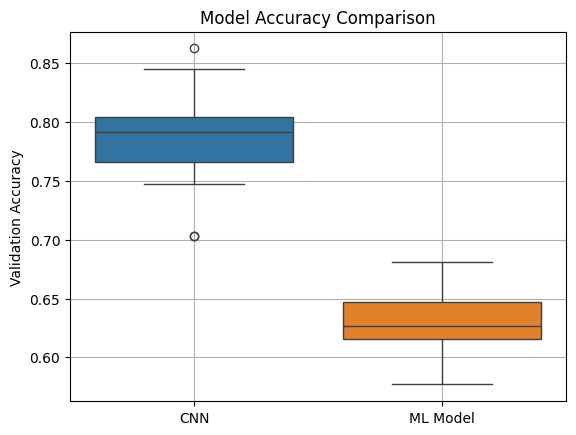

In [59]:
import pandas as pd     #Visualizing the accuracies using box plots
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'CNN': cnn_accuracies, 
    'ML Model': ml_accuracies
})

sns.boxplot(data=df)
plt.title("Model Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()


The Boxplot comparing validation accuracies of CNN vs. ML (Random Forest) across 15-fold Repeated K-Fold Cross Validation.
The CNN model not only achieves a higher median accuracy, but also displays less variability, indicating more stable performance.
This supports our statistical test (t-statistic = 18.4204, p-value < 0.0001) confirming that the CNN significantly outperforms the ML model.